In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## Phase-Flip Errors

In quantum computing, **phase-flip errors** are another important type of error besides bit-flips. These errors are described by **Z gates**. Correcting both bit-flip and phase-flip errors allows us to correct **arbitrary single-qubit errors**.

Unfortunately, the **3-bit repetition code** does not protect against phase-flip errors. For example, encoding
$$
\alpha |0\rangle + \beta |1\rangle
$$
gives
$$
\alpha |000\rangle + \beta |111\rangle
$$
If a phase-flip occurs on the middle qubit:
$$
(I \otimes Z \otimes I)(\alpha |000\rangle + \beta |111\rangle)
= \alpha |000\rangle - \beta |111\rangle
$$
This is equivalent to encoding
$$
\alpha |0\rangle - \beta |1\rangle
$$

Since this is still a valid encoded state, the error **cannot be detected**, and the syndrome incorrectly indicates **no error**.

Moreover, if phase-flip errors occur with probability (p), the chance of an error after decoding becomes
$$
3p(1-p)^2 + p^3
$$
which is larger than (p) for (0 < p < 1/2). Thus, the 3-bit repetition code actually **increases** phase-flip errors.

To detect phase-flip errors, we modify the repetition code by applying **Hadamard gates** to each qubit after the CNOT operations. This forms the basis for building the **Shor code**.

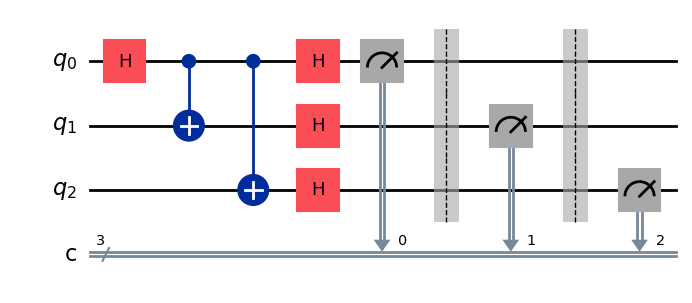

In [2]:
#Prepare of qubit
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.h(0)
qc.h(1)
qc.h(2)
# Measure qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

A **Hadamard gate** transforms the computational basis states as follows:

$$
|0\rangle \rightarrow |+\rangle
\quad \text{and} \quad
|1\rangle \rightarrow |-\rangle
$$
Applying Hadamard gates to each qubit after encoding transforms the single-qubit state
$$
\alpha |0\rangle + \beta |1\rangle
$$
into
$$
\alpha |+++\rangle + \beta |---\rangle
$$
where
$$
|+++\rangle = |+\rangle \otimes |+\rangle \otimes |+\rangle
$$
and
$$
|---\rangle = |-\rangle \otimes |-\rangle \otimes |-\rangle
$$
A **phase-flip error** (a **Z gate**) flips between the states
$$
|+\rangle \leftrightarrow |-\rangle 
$$

Therefore, this encoding allows **phase-flip errors to be detected and corrected**. The earlier error-detection circuit can then be modified accordingly.

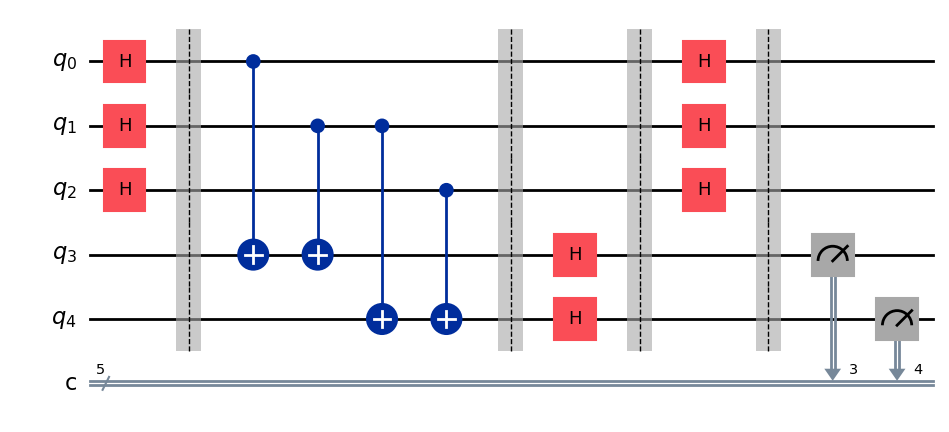

In [3]:
# Create circuit (3 data qubits + 2 ancilla qubits)
qc = QuantumCircuit(5, 5)

# Convert to phase-flip detection basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

#Syndrome Extraction
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()

# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()

# Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# Measurement
qc.measure(3, 3)
qc.measure(4, 4)

# Draw circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

The following four circuit diagrams describe how our modified version of the 3-bit repetition code, including the encoding step and the error detection step, functions when at most one phase-flip error occurs. The behavior is similar to the ordinary 3-bit repetition code for bit-flips.

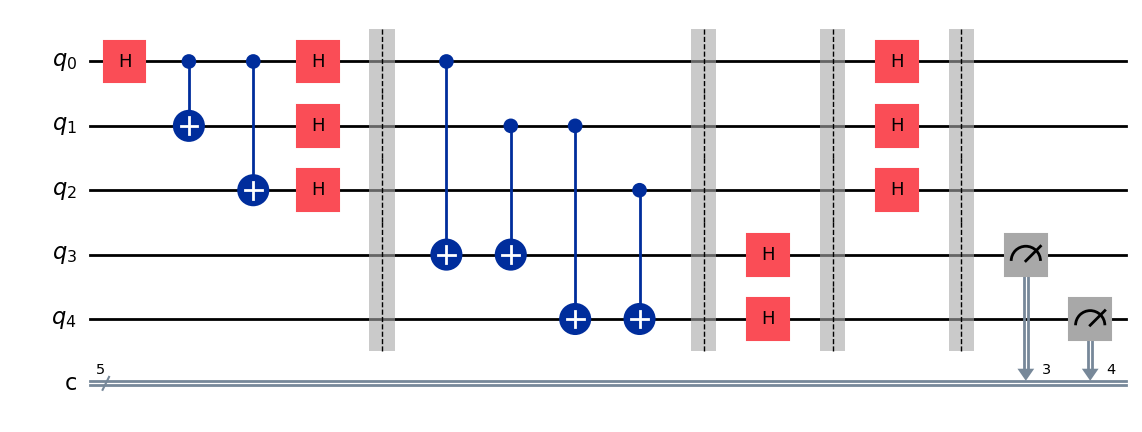

In [4]:
# Create circuit (3 data qubits + 2 ancilla qubits)
qc = QuantumCircuit(5, 5)

#State Preparation and Encoding 
qc.h(0)          
qc.cx(0, 1)      
qc.cx(0, 2)

# Convert to phase-flip detection basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

#Syndrome Extraction
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()

# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()

# Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# Measurement
qc.measure(3, 3)
qc.measure(4, 4)

# Draw circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

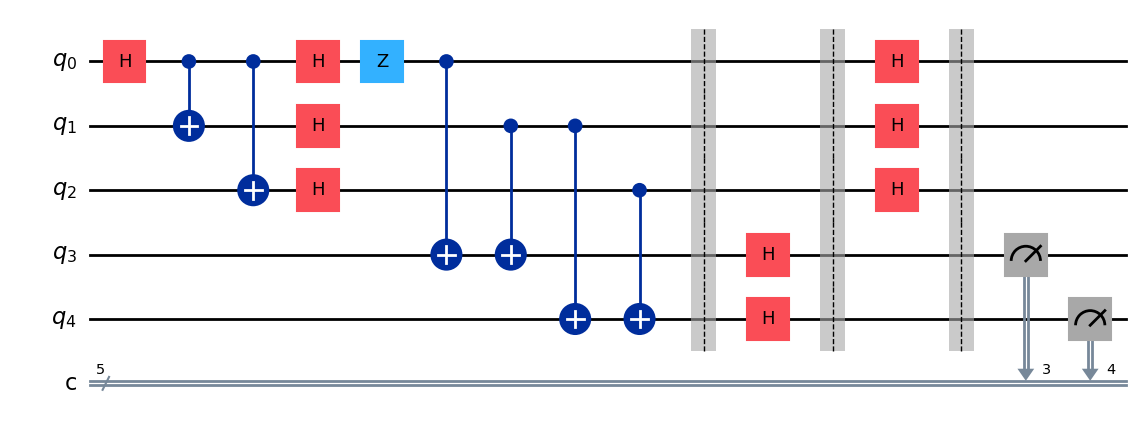

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create circuit (3 data qubits + 2 ancilla qubits)
qc = QuantumCircuit(5, 5)

#State Preparation and Encoding 
qc.h(0)          
qc.cx(0, 1)      
qc.cx(0, 2)

# Convert to phase-flip detection basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(0)


#Syndrome Extraction
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()

# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()

# Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# Measurement
qc.measure(3, 3)
qc.measure(4, 4)

# Draw circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

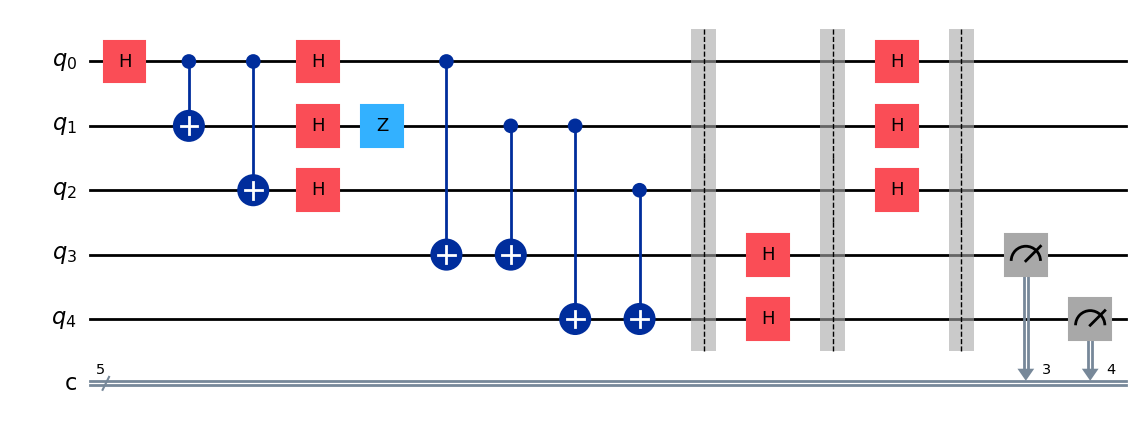

In [6]:
# Create circuit (3 data qubits + 2 ancilla qubits)
qc = QuantumCircuit(5, 5)

#State Preparation and Encoding 
qc.h(0)          
qc.cx(0, 1)      
qc.cx(0, 2)

# Convert to phase-flip detection basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(1)


#Syndrome Extraction
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()

# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()

# Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# Measurement
qc.measure(3, 3)
qc.measure(4, 4)

# Draw circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

In [7]:
# Create circuit (3 data qubits + 2 ancilla qubits)
qc = QuantumCircuit(5, 5)

#State Preparation and Encoding 
qc.h(0)          
qc.cx(0, 1)      
qc.cx(0, 2)

# Convert to phase-flip detection basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(2)


#Syndrome Extraction
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()

# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()

# Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# Measurement
qc.measure(3, 3)
qc.measure(4, 4)

# Draw circuit
qc.draw('mpl')

# Text version
print(qc.draw('text'))

     ┌───┐          ┌───┐                          ░       ░ ┌───┐ ░       
q_0: ┤ H ├──■────■──┤ H ├───────■──────────────────░───────░─┤ H ├─░───────
     └───┘┌─┴─┐  │  ├───┤       │                  ░       ░ ├───┤ ░       
q_1: ─────┤ X ├──┼──┤ H ├───────┼────■────■────────░───────░─┤ H ├─░───────
          └───┘┌─┴─┐├───┤┌───┐  │    │    │        ░       ░ ├───┤ ░       
q_2: ──────────┤ X ├┤ H ├┤ Z ├──┼────┼────┼────■───░───────░─┤ H ├─░───────
               └───┘└───┘└───┘┌─┴─┐┌─┴─┐  │    │   ░ ┌───┐ ░ └───┘ ░ ┌─┐   
q_3: ─────────────────────────┤ X ├┤ X ├──┼────┼───░─┤ H ├─░───────░─┤M├───
                              └───┘└───┘┌─┴─┐┌─┴─┐ ░ ├───┤ ░       ░ └╥┘┌─┐
q_4: ───────────────────────────────────┤ X ├┤ X ├─░─┤ H ├─░───────░──╫─┤M├
                                        └───┘└───┘ ░ └───┘ ░       ░  ║ └╥┘
c: 5/═════════════════════════════════════════════════════════════════╩══╩═
                                                                      3  4 


## Phase-Flip Error Syndrome Table (Code Style)

In [8]:
| State | Syndrome | Correction |    |           |
| ----- | -------- | ---------- | -- | --------- |
| α     | +++⟩ + β | ---⟩       | 00 | I ⊗ I ⊗ I |
| α     | ++-⟩ + β | --+⟩       | 01 | I ⊗ I ⊗ Z |
| α     | +-+⟩ + β | -+-⟩       | 11 | I ⊗ Z ⊗ I |
| α     | -++⟩ + β | +--⟩       | 10 | Z ⊗ I ⊗ I |



SyntaxError: invalid character '⟩' (U+27E9) (496167626.py, line 3)


- A **phase-flip error** flips $|+\rangle \leftrightarrow |-\rangle$.  
- The **syndrome** identifies which qubit was flipped.  
- Applying the corresponding **Z gate** corrects the error.

> Note: This code **cannot correct bit-flip errors**. Combining this with the bit-flip repetition code yields the **9-qubit Shor code**, which corrects both bit-flip and phase-flip errors.

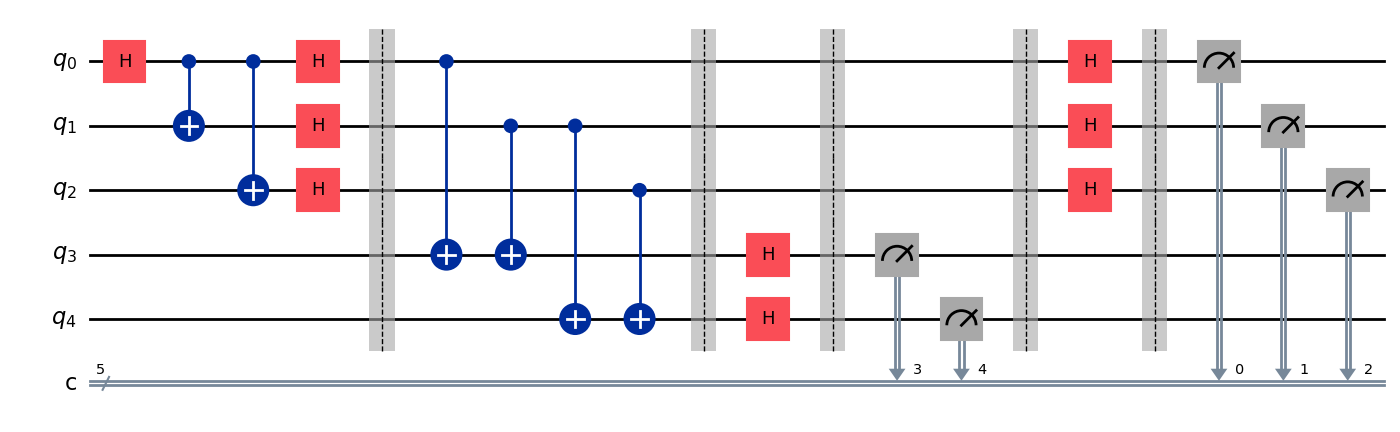

In [9]:
# 3 data qubits + 2 ancilla qubits, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)        
qc.cx(0, 1)    
qc.cx(0, 2)

#Prepare for phase-flip detection
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

#Syndrome measurement
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()
#extract syndrome
qc.measure(3, 3)
qc.measure(4, 4)
qc.barrier()
#Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Draw circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

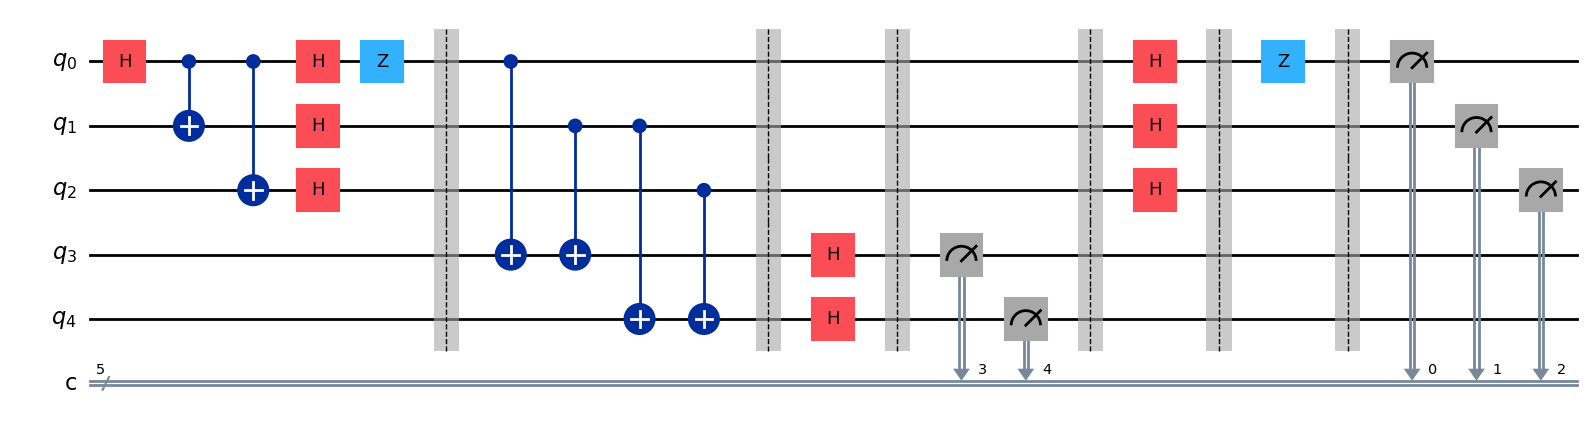

In [10]:
# 3 data qubits + 2 ancilla qubits, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)        
qc.cx(0, 1)    
qc.cx(0, 2)

#Prepare for phase-flip detection
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(0)
qc.barrier()

#Syndrome measurement
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()
#extract syndrome
qc.measure(3, 3)
qc.measure(4, 4)
qc.barrier()
#Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
qc.z(0)
qc.barrier()
#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Draw circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

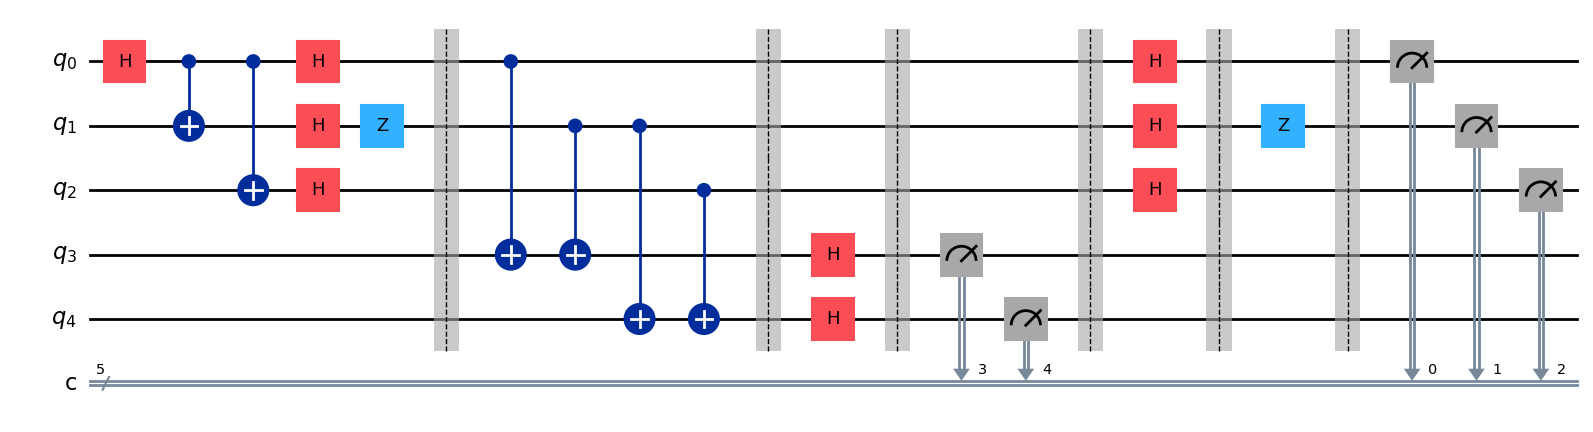

In [11]:
# 3 data qubits + 2 ancilla qubits, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)        
qc.cx(0, 1)    
qc.cx(0, 2)

#Prepare for phase-flip detection
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(1)
qc.barrier()

#Syndrome measurement
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()
#extract syndrome
qc.measure(3, 3)
qc.measure(4, 4)
qc.barrier()
#Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
qc.z(1)
qc.barrier()
#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Draw circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

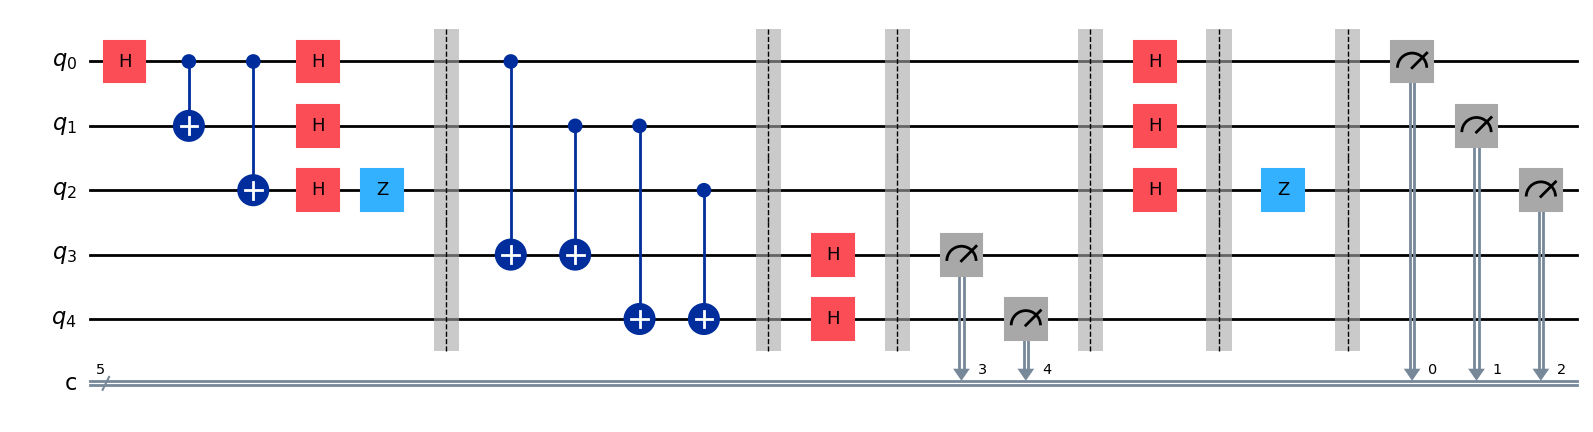

In [12]:
# 3 data qubits + 2 ancilla qubits, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)        
qc.cx(0, 1)    
qc.cx(0, 2)

#Prepare for phase-flip detection
qc.h(0)
qc.h(1)
qc.h(2)
qc.z(2)
qc.barrier()

#Syndrome measurement
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
# Convert ancilla qubits to measurement basis
qc.h(3)
qc.h(4)
qc.barrier()
#extract syndrome
qc.measure(3, 3)
qc.measure(4, 4)
qc.barrier()
#Return data qubits to computational basis
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
qc.z(2)
qc.barrier()
# Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Draw circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))